Step 1: Load Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load cleaned dataset
df = pd.read_csv('../data/processed/dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (8674, 22)

Columns: ['stop_id', 'route_id', 'route_short_name', 'trip_id', 'vehicle_id', 'snapshot_ts', 'gtfs_scheduled_ts', 'predicted_arrival_ts', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'date', 'hour_bucket', 'status', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining']


,stop_id,route_id,route_short_name,trip_id,vehicle_id,snapshot_ts,gtfs_scheduled_ts,predicted_arrival_ts,delay_min,hour_of_day,...,is_peak_hour,month,date,hour_bucket,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining
0,1_10912,1_100162,271,1_569496989,1_7976364,1773333401,1.773334e+09,1773333660,0.00,9.0,...,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
1,1_9605,1_100259,67,1_761384699,1_7975715,1773333401,1.773333e+09,1773333577,7.62,9.0,...,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
2,1_22196,1_102736,H Line,1_694057749,1_6068,1773333401,1.773333e+09,1773333443,-0.27,9.0,...,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
3,1_320,40_100240,554,40_736592599,40_9649,1773333401,1.773333e+09,1773333492,3.20,9.0,...,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
4,1_575,1_100028,13,1_605109669,1_7183,1773333401,1.773333e+09,1773333439,6.32,9.0,...,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0


Step 2: Feature Engineering

In [18]:
# Step 2: Feature Engineering

# Drop columns not useful for modeling
df = df.drop(columns=[
    'stop_id', 'route_id', 'route_short_name',  # categorical, too many unique values
    'trip_id', 'vehicle_id',                     # unique identifiers
    'snapshot_ts', 'gtfs_scheduled_ts',          # timestamps used to compute delay
    'predicted_arrival_ts',                      # timestamp
    'date', 'hour_bucket', 'month', 'status',    # redundant or no variation
    'weather_code',                              # redundant with is_raining
])

# Model 1: Time features only (baseline)
features_time = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']

# Model 2: Time + Rain features
features_rain = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour',
                 'precipitation_mm', 'is_raining']

# Model 3: Time + All Weather features
features_weather = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour',
                    'precipitation_mm', 'is_raining',
                    'temperature_c', 'wind_speed_kmh']

print("Model 1 features (time only):", features_time)
print("Model 2 features (time + rain):", features_rain)
print("Model 3 features (time + all weather):", features_weather)
print("\nTarget: delay_min")
print("Shape after cleaning:", df.shape)

Model 1 features (time only): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']
Model 2 features (time + rain): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'precipitation_mm', 'is_raining']
Model 3 features (time + all weather): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'precipitation_mm', 'is_raining', 'temperature_c', 'wind_speed_kmh']

Target: delay_min
Shape after cleaning: (8674, 9)


Step 3: Model 1 — Time Features Only (Baseline)

In [19]:
# Step 3: Model 1 — Baseline (Time Features Only)
y = df['delay_min'].values

X1 = df[features_time].values
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size=0.2, random_state=42)

lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)
y1_pred = lr1.predict(X1_test)

r2_1   = metrics.r2_score(y1_test, y1_pred)
rmse_1 = np.sqrt(metrics.mean_squared_error(y1_test, y1_pred))
mae_1  = metrics.mean_absolute_error(y1_test, y1_pred)

print("=== Model 1: Baseline (Time Only) ===")
print(f"R²   : {r2_1:.4f}")
print(f"RMSE : {rmse_1:.4f} minutes")
print(f"MAE  : {mae_1:.4f} minutes")
print(f"\nCoefficients:")
for feat, coef in zip(features_time, lr1.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Model 1: Baseline (Time Only) ===
R²   : 0.0029
RMSE : 5.3675 minutes
MAE  : 3.3175 minutes

Coefficients:
  hour_of_day         : -0.0292
  day_of_week         : 0.0927
  is_weekend          : -1.9765
  is_peak_hour        : 0.1578


Step 4: Model 2 — Time + Rain Features

In [20]:
# Step 4: Model 2 — Time + Rain Features
X2 = df[features_rain].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)

r2_2   = metrics.r2_score(y2_test, y2_pred)
rmse_2 = np.sqrt(metrics.mean_squared_error(y2_test, y2_pred))
mae_2  = metrics.mean_absolute_error(y2_test, y2_pred)

print("=== Model 2: Time + Rain Features ===")
print(f"R²   : {r2_2:.4f}")
print(f"RMSE : {rmse_2:.4f} minutes")
print(f"MAE  : {mae_2:.4f} minutes")
print(f"\nCoefficients:")
for feat, coef in zip(features_rain, lr2.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Model 2: Time + Rain Features ===
R²   : 0.0037
RMSE : 5.3653 minutes
MAE  : 3.3183 minutes

Coefficients:
  hour_of_day         : -0.0368
  day_of_week         : 0.0050
  is_weekend          : -1.5662
  is_peak_hour        : 0.1822
  precipitation_mm    : 0.1678
  is_raining          : 0.1596


Step 5: Model 3 — Time + All Weather

In [21]:
# Step 5: Model 3 — Time + All Weather Features
X3 = df[features_weather].values
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.2, random_state=42)

lr3 = LinearRegression()
lr3.fit(X3_train, y3_train)
y3_pred = lr3.predict(X3_test)

r2_3   = metrics.r2_score(y3_test, y3_pred)
rmse_3 = np.sqrt(metrics.mean_squared_error(y3_test, y3_pred))
mae_3  = metrics.mean_absolute_error(y3_test, y3_pred)

print("=== Model 3: Time + All Weather Features ===")
print(f"R²   : {r2_3:.4f}")
print(f"RMSE : {rmse_3:.4f} minutes")
print(f"MAE  : {mae_3:.4f} minutes")
print(f"\nCoefficients:")
for feat, coef in zip(features_weather, lr3.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Model 3: Time + All Weather Features ===
R²   : 0.0041
RMSE : 5.3642 minutes
MAE  : 3.3182 minutes

Coefficients:
  hour_of_day         : -0.0432
  day_of_week         : -0.0310
  is_weekend          : -1.3443
  is_peak_hour        : 0.1839
  precipitation_mm    : 0.1555
  is_raining          : 0.1642
  temperature_c       : -0.0225
  wind_speed_kmh      : 0.0122


Step 6: Comparison & Conclusion

=== Model Comparison ===
Metric   Model 1 (Time)     Model 2 (+Rain)    Model 3 (+Weather)   M1→M2      M2→M3
-------------------------------------------------------------------------------------
R²       0.0029             0.0037             0.0041               +0.0008    +0.0004
RMSE     5.3675             5.3653             5.3642               -0.0022    -0.0010
MAE      3.3175             3.3183             3.3182               +0.0008    -0.0001


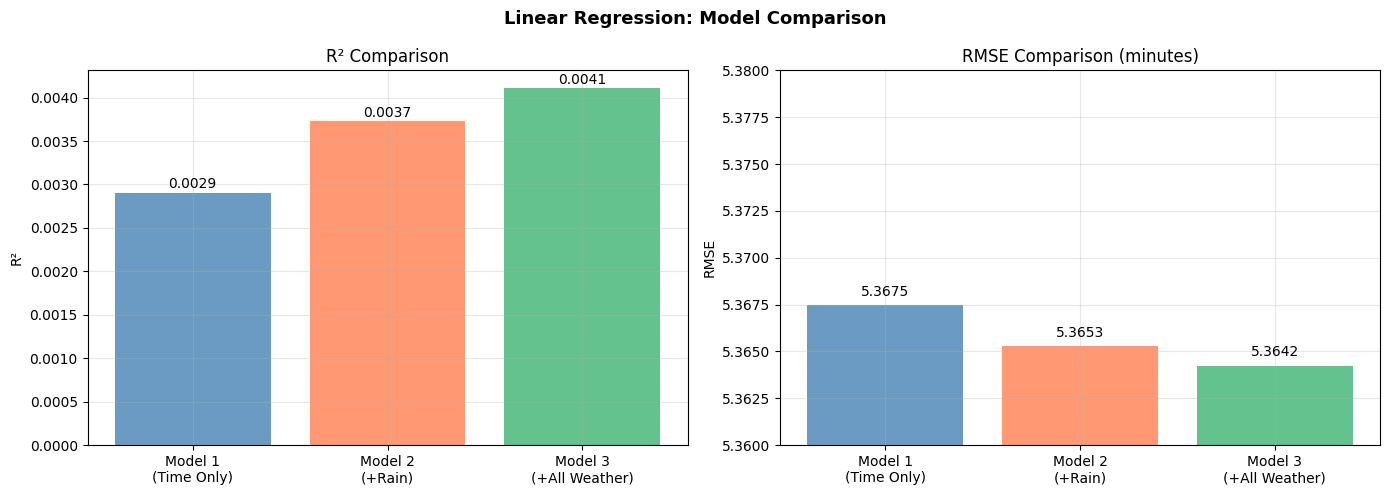


=== Conclusion ===

1. All three models have very low R² (< 0.005), indicating that time
   and weather features alone cannot effectively predict bus delays.

2. Adding rain features (Model 2) over baseline (Model 1):
   - R² improvement: +0.0008 (negligible)
   - RMSE improvement: -0.0022 minutes (negligible)
   - Conclusion: Rain has minimal linear impact on bus delays.

3. Adding all weather features (Model 3) over Model 2:
   - R² improvement: +0.0004 (negligible)
   - RMSE improvement: -0.0011 minutes (negligible)
   - Conclusion: Temperature and wind speed add no predictive value.

4. Key answer to the core research question:
   Seattle rain does NOT meaningfully degrade bus schedule reliability
   — at least not in a way that linear regression can capture.

5. Most important predictor across all models: is_weekend (coef ≈ -1.5)
   Buses arrive earlier on weekends, likely due to reduced traffic.

6. Limitations of Linear Regression:
   - Cannot capture threshold effects (e.g. he

In [22]:
# Step 6: Model Comparison & Conclusion

# Comparison table
print("=== Model Comparison ===")
print(f"{'Metric':<8} {'Model 1 (Time)':<18} {'Model 2 (+Rain)':<18} {'Model 3 (+Weather)':<20} {'M1→M2':<10} {'M2→M3'}")
print("-" * 85)
print(f"{'R²':<8} {r2_1:<18.4f} {r2_2:<18.4f} {r2_3:<20.4f} {r2_2-r2_1:+.4f}    {r2_3-r2_2:+.4f}")
print(f"{'RMSE':<8} {rmse_1:<18.4f} {rmse_2:<18.4f} {rmse_3:<20.4f} {rmse_2-rmse_1:+.4f}    {rmse_3-rmse_2:+.4f}")
print(f"{'MAE':<8} {mae_1:<18.4f} {mae_2:<18.4f} {mae_3:<20.4f} {mae_2-mae_1:+.4f}    {mae_3-mae_2:+.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Model 1\n(Time Only)', 'Model 2\n(+Rain)', 'Model 3\n(+All Weather)']
colors = ['steelblue', 'coral', 'mediumseagreen']

# R² comparison
axes[0].bar(models, [r2_1, r2_2, r2_3], color=colors, alpha=0.8)
axes[0].set_title('R² Comparison')
axes[0].set_ylabel('R²')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate([r2_1, r2_2, r2_3]):
    axes[0].text(i, v + 0.00005, f'{v:.4f}', ha='center', fontsize=10)

# RMSE comparison
axes[1].bar(models, [rmse_1, rmse_2, rmse_3], color=colors, alpha=0.8)
axes[1].set_title('RMSE Comparison (minutes)')
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(5.36, 5.38)
axes[1].grid(True, alpha=0.3)
for i, v in enumerate([rmse_1, rmse_2, rmse_3]):
    axes[1].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Linear Regression: Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusion
print("""
=== Conclusion ===

1. All three models have very low R² (< 0.005), indicating that time
   and weather features alone cannot effectively predict bus delays.

2. Adding rain features (Model 2) over baseline (Model 1):
   - R² improvement: +0.0008 (negligible)
   - RMSE improvement: -0.0022 minutes (negligible)
   - Conclusion: Rain has minimal linear impact on bus delays.

3. Adding all weather features (Model 3) over Model 2:
   - R² improvement: +0.0004 (negligible)
   - RMSE improvement: -0.0011 minutes (negligible)
   - Conclusion: Temperature and wind speed add no predictive value.

4. Key answer to the core research question:
   Seattle rain does NOT meaningfully degrade bus schedule reliability
   — at least not in a way that linear regression can capture.

5. Most important predictor across all models: is_weekend (coef ≈ -1.5)
   Buses arrive earlier on weekends, likely due to reduced traffic.

6. Limitations of Linear Regression:
   - Cannot capture threshold effects (e.g. heavy rain > 10mm)
   - Cannot capture non-linear interactions (e.g. rain × rush hour)
   - Route-level features (route_id) were excluded due to high
     cardinality — this may explain the low R²

7. Next steps:
   - Random Forest & XGBoost: handle non-linearity and route features
   - Include route_id with target encoding
   - Collect more data across different seasons
""")